<a href="https://colab.research.google.com/github/Gsusjs/carisurg-portfolio/blob/main/notebooks/Week7_Tutorial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Complex Model Development and Benchmark Comparison

## Aim

The aim of this notebook is to develop and evaluate a more complex machine learning model for predicting
Emergency Severity Index (ESI) levels from emergency department triage data.

A Random Forest classifier is implemented as the complex model and compared against the Week 6 Logistic
Regression baseline. The same cleaning process and train/test split from Week 6 are reused to ensure a
fair comparison.

## 1. Import Libraries

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_SEED = 42

pd.set_option("display.width", 120)

print("Libraries loaded successfully")
print("Random seed:", RANDOM_SEED)


Libraries loaded successfully
Random seed: 42


## 2. Load Dataset

The Yale EMMLC triage dataset is loaded. The same dataset preparation approach used during Week 6 is
followed to maintain a consistent evaluation pipeline.

The path check below keeps the Colab / Google Drive workflow working, but also lets the notebook run
without Drive mounted (e.g. if it's moved into GitHub and run with a local copy of the CSV alongside it).

In [5]:
RAW_FILE = "yaleemmlc_admissionprediction_triage.csv"

DRIVE_PATH = "/content/drive/MyDrive/CariSurg/" + RAW_FILE

DATA_PATH = DRIVE_PATH if os.path.exists(DRIVE_PATH) else RAW_FILE

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)

df_raw.head()


Dataset shape: (55121, 226)


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Rebuild Week 6 Cleaning

The cleaning rules from Week 6 are reused. This prevents differences in preprocessing from affecting the
comparison between the baseline and complex model.

In [6]:
VITAL_COLS = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose"
]


def clean_triage_data(raw):

    df = raw.copy()

    df = df.drop(
        columns=[c for c in df.columns if c.startswith("Unnamed")],
        errors="ignore"
    )

    for col in VITAL_COLS:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["esi"] = pd.to_numeric(
        df["esi"],
        errors="coerce"
    )

    df = df[
        df["esi"].isin([1, 2, 3, 4, 5])
    ]

    df.loc[
        (df["triage_vital_temp"] < 90) |
        (df["triage_vital_temp"] > 110),
        "triage_vital_temp"
    ] = np.nan

    df.loc[
        df["triage_vital_o2"] > 100,
        "triage_vital_o2"
    ] = np.nan

    # .str.strip() before .str.lower() -- matches Week 6 exactly and stops
    # values like " Female " from falling through the map() as missing.
    df["gender"] = (
        df["gender"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "male": 0,
            "m": 0,
            "female": 1,
            "f": 1
        })
    )

    for col in VITAL_COLS + ["age", "gender"]:
        df[col] = df[col].fillna(
            df[col].median()
        )

    df["esi"] = df["esi"].astype(int)

    return df


df = clean_triage_data(df_raw)

print(df.shape)


(55121, 225)


## 4. Feature Selection (Same as Week 6)

Variables unavailable during triage are removed to prevent data leakage.

In [7]:
TARGET = "esi"

LEAKAGE = [
    "disposition",
    "previousdispo"
]

ADMIN = [
    "dep_name",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin"
]

DEMOGRAPHICS = [
    "age",
    "gender",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status"
]

FEATURES = [
    c for c in df.columns
    if c != TARGET
    and c not in LEAKAGE + ADMIN + DEMOGRAPHICS
]

X = df[FEATURES]
y = df[TARGET]

print("Features:", len(FEATURES))


Features: 208


## 5. Reuse Week 6 Split

The Week 6 train/test split is recreated exactly. Using the same random state and stratification ensures
the complex model is evaluated against the same patient groups as the baseline.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (44096, 208)
Testing: (11025, 208)


## 6. Train Week 6 Baseline Again

Logistic Regression is retrained using the same split to provide a direct comparison.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED
)

baseline.fit(
    X_train_scaled,
    y_train
)

baseline_pred = baseline.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        baseline_pred,
        digits=3
    )
)


              precision    recall  f1-score   support

           1      0.444     0.250     0.320        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.587     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.582     0.463     0.492     11025
weighted avg      0.666     0.667     0.661     11025



## 7. Train Complex Model - Random Forest

Random Forest is selected as the complex model because it can capture nonlinear relationships between
clinical variables and ESI levels. Class weighting is used because ESI classes are imbalanced.

In [10]:
start = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_time = time.time() - start

rf_pred = rf.predict(
    X_test
)

print("Training time:", round(rf_time, 2), "seconds")


Training time: 62.45 seconds


## 8. Complex Model Evaluation

Performance is evaluated using accuracy, precision, recall and F1-score for each ESI class.

In [18]:
print(
    classification_report(
        y_test,
        rf_pred,
        digits=3
    )
)


              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.712     0.569     0.633      3585
           3      0.628     0.792     0.701      5402
           4      0.613     0.438     0.511      1779
           5      0.420     0.119     0.186       243

    accuracy                          0.647     11025
   macro avg      0.475     0.384     0.406     11025
weighted avg      0.647     0.647     0.636     11025



## 9. Confusion Matrix

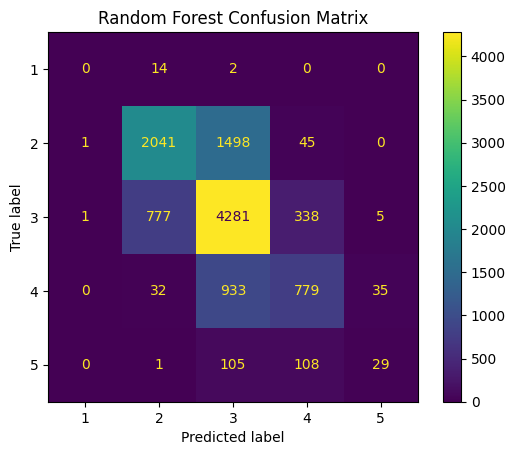

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()


## 10. Benchmark Comparison Table

The complex model is compared with the Week 6 Logistic Regression baseline.
`zero_division=0` is set on precision and recall so a class with no predicted samples produces a `0`
instead of an `UndefinedMetricWarning`.

In [24]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, baseline_pred, average="macro", zero_division=0),
        precision_score(y_test, rf_pred, average="macro", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred, average="macro", zero_division=0),
        recall_score(y_test, rf_pred, average="macro", zero_division=0)
    ],

    "F1": [
        f1_score(y_test, baseline_pred, average="macro", zero_division=0),
        f1_score(y_test, rf_pred, average="macro", zero_division=0)
    ]

})

print("Table 1. Draft Benchmark Comparison (Baseline vs Complex Model)")

comparison.round(3)

Table 1. Draft Benchmark Comparison (Baseline vs Complex Model)


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.667,0.582,0.463,0.492
1,Random Forest,0.647,0.475,0.384,0.406


## 11. Save Benchmark Table to /docs

Checking for `tabulate` first, since `DataFrame.to_markdown()` depends on it. If the import fails,
run `!pip install tabulate` in a new cell above and re-run this one.

In [25]:
try:
    import tabulate
    print("Tabulate available")
except ImportError:
    print("Install tabulate if markdown export fails: !pip install tabulate")

os.makedirs("docs", exist_ok=True)

with open("docs/week7_benchmark.md", "w") as f:
    f.write(
        comparison.round(3)
        .to_markdown(index=False)
    )

print("Benchmark table saved")


Tabulate available
Benchmark table saved


## 13. Conclusion

Random Forest was successfully implemented as the complex classification model using the same data preparation and train/test split as the Week 6 baseline. The model was evaluated using per-class precision, recall, and F1-score, and compared directly with Logistic Regression using the benchmark table. Although Random Forest met the implementation and evaluation requirements, Logistic Regression achieved higher macro-level precision, recall, and F1-score on this dataset. This suggests that increasing model complexity did not improve predictive performance for this task.